<a href="https://colab.research.google.com/github/mmanishyadav325-ux/ubiquitous-couscous/blob/main/level_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LEVEL 1

# TASK 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load the dataset:
df=pd.read_csv("/content/Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
#Name of row and colunms.
df.shape

(9551, 21)

Determine the top three most
common cuisines in the dataset.

In [ ]:
cuisine_count=df['Cuisines'].str.split(',',).explode().value_counts()

top_three_cuisine=cuisine_count.head(3)
print(top_three_cuisine)

Cuisines
North Indian    2992
 Chinese        1880
 Fast Food      1314
Name: count, dtype: int64


1.1 DETERMINE THE TOP THREE MOST COMMON CUISINE.

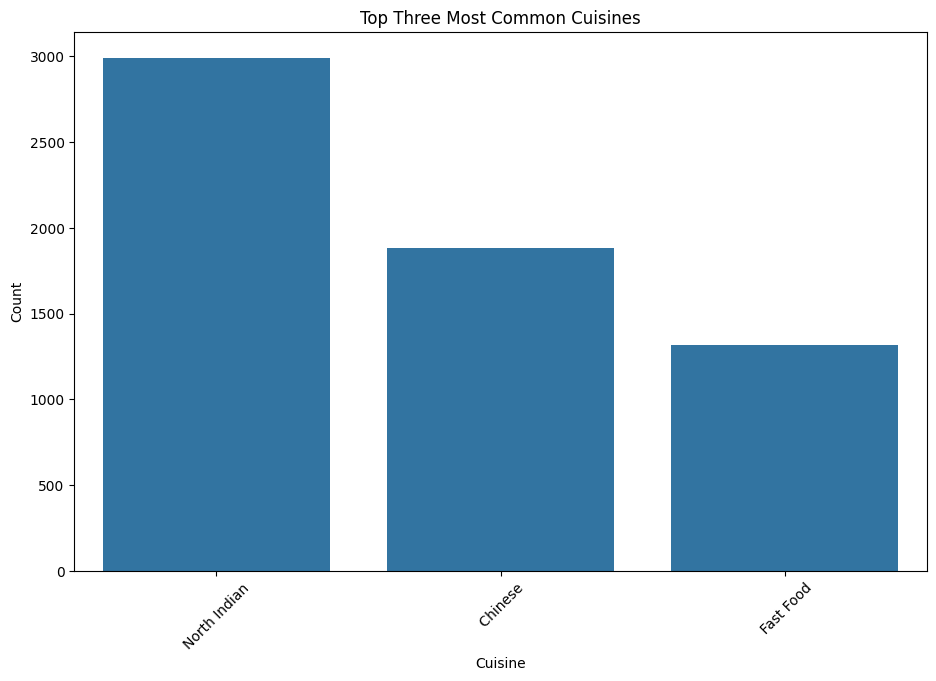

In [ ]:
top_three_cuisine = top_three_cuisine.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11,7))

sns.barplot(
    x=top_three_cuisine.index,
    y=top_three_cuisine.values,
    ax=ax
)

plt.title('Top Three Most Common Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

1.2 CALCULATE THE % OF RESTRAURANTS THAT SERVE EACH OF TOP CUISINE  

In [ ]:
top_restraurants=len(df)
percentage_per_cuisine=(top_three_cuisine/top_restraurants)*100
print(percentage_per_cuisine)


Cuisines
North Indian    31.326563
 Chinese        19.683803
 Fast Food      13.757722
Name: count, dtype: float64


In [ ]:
print('percentage of restaurants for top three cuisine ')
percentage_per_cuisine


percentage of restaurants for top three cuisine 


,count
Cuisines,
North Indian,31.326563
Chinese,19.683803
Fast Food,13.757722


Text(0.5, 1.0, 'Percentage of Resrtaurents serving Top Three Cuisine')

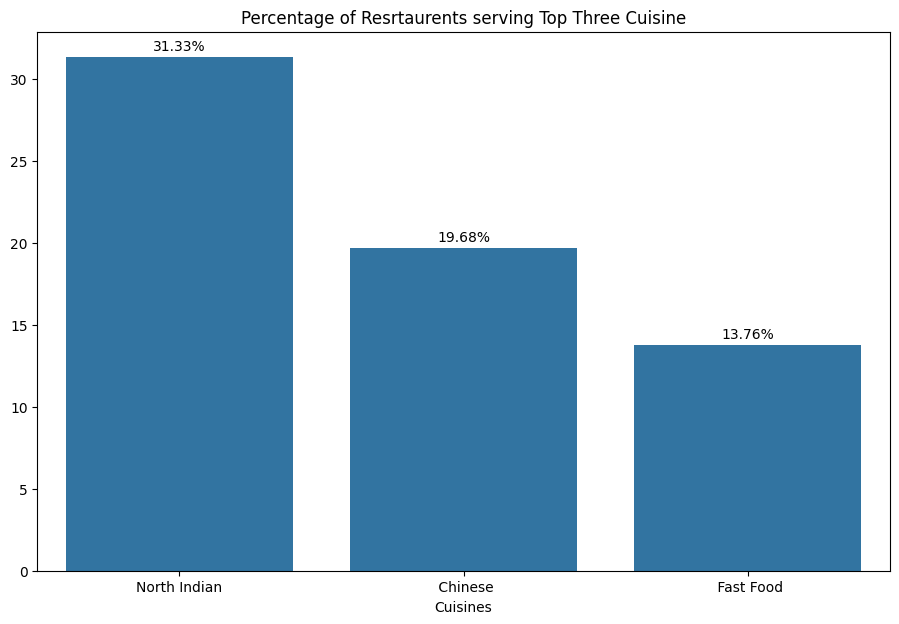

In [ ]:
fig,ax=plt.subplots(figsize=(11,7))
ab=sns.barplot(x=percentage_per_cuisine.index,y=percentage_per_cuisine.values)
for bar in ab.containers[0]:
  height=bar.get_height()
  ab.annotate(f'{height :.2f}%', xy=(bar.get_x()+bar.get_width()/2, height), xytext=(0,3),textcoords='offset points', ha='center',va='bottom')
plt.title('Percentage of Resrtaurents serving Top Three Cuisine')

# **TASK 2**

# **Task: City Analysis**

 `Identify the city with the height number of retaurents`

In [ ]:
import pandas as pd
df=pd.read_csv("/content/Dataset .csv")
print(df['City'].value_counts()[[0]].index[0])

New Delhi


/tmp/ipykernel_859/234385267.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df['City'].value_counts()[[0]].index[0])



# calculate the average for restaurents in each day

In [ ]:
# create a dataframe  tha holds the average tha rating for restaunts in each city;
average_restaurant_rating = df.groupby('City').agg(
    Average_rating=('Aggregate rating', 'mean')
).sort_values(by='Average_rating', ascending=False)

print(average_restaurant_rating)

                  Average_rating
City                            
Inner City              4.900000
Quezon City             4.800000
Makati City             4.650000
Pasig City              4.633333
Mandaluyong City        4.625000
...                          ...
New Delhi               2.438845
Montville               2.400000
Mc Millan               2.400000
Noida                   2.036204
Faridabad               1.866932

[141 rows x 1 columns]


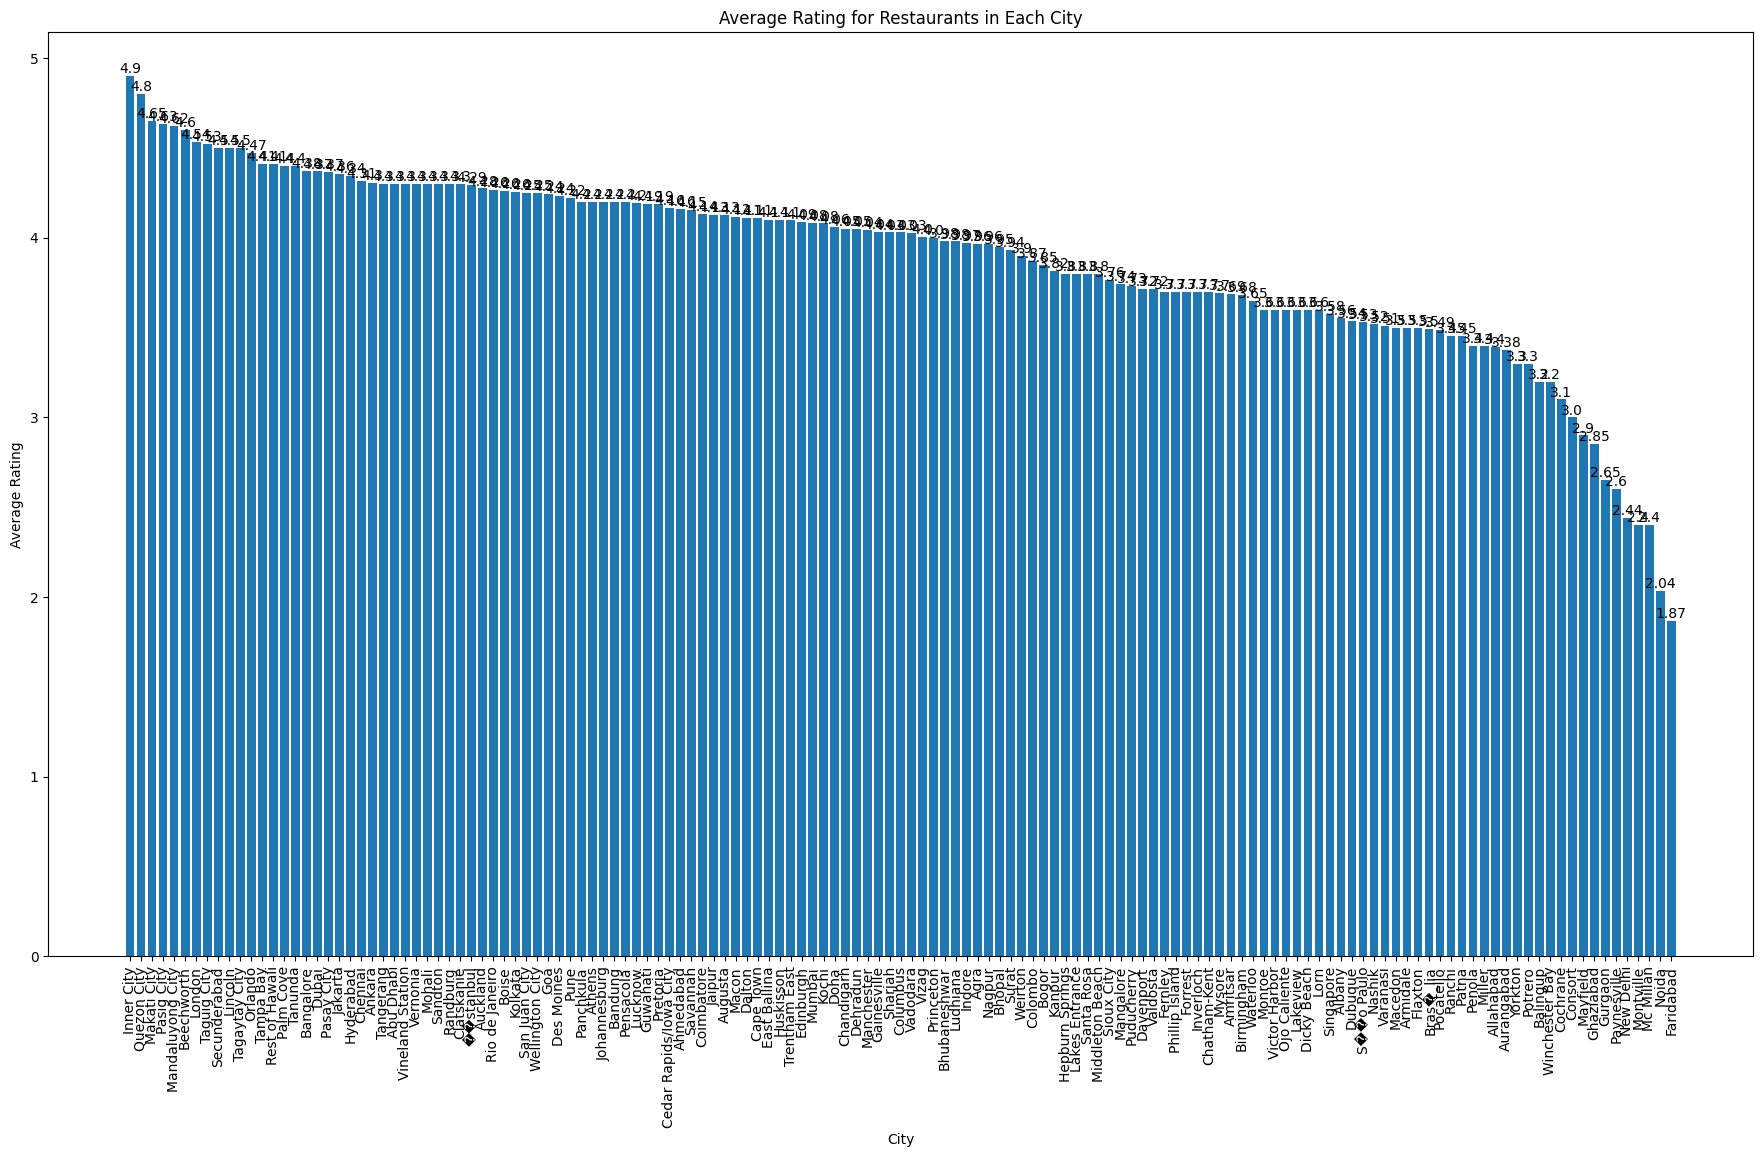

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(22,12))

# Grouping data
average_restaurent_rating = df.groupby('City').agg(
    average_rating=('Aggregate rating', 'mean')
).sort_values(by='average_rating', ascending=False)

# Plotting
bars = plt.bar(
    average_restaurent_rating.index,
    average_restaurent_rating['average_rating']
)

# Adding labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(), 2),
        ha='center',
        va='bottom'
    )

# Adding title and labels
plt.title('Average Rating for Restaurants in Each City')
plt.xlabel('City')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)

plt.show()

# The City with the heighest average rating

In [ ]:
average_restaurent_rating = df.groupby('City').agg(
    average_rating=('Aggregate rating', 'mean')
).sort_values(by='average_rating', ascending=False)

print("The city with the highest average rating is:",
      average_restaurent_rating.index[0])


The city with the highest average rating is: Inner City


# **TASK 3**

# **TAsk:Price Range Distribution**

# Create a histogram or bar chart to visualize the distribution of price range among the restaurents.

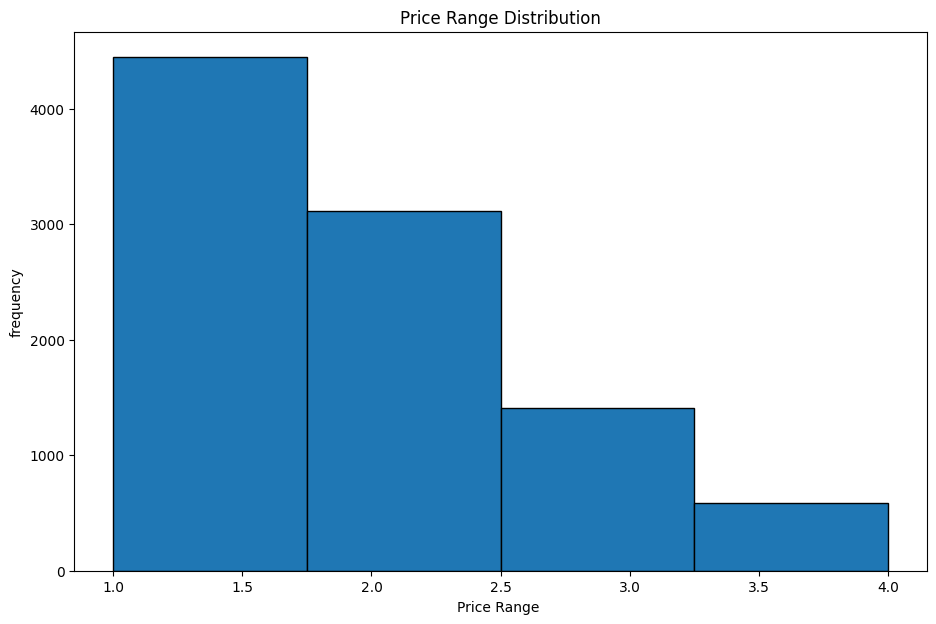

In [ ]:
plt.figure(figsize=(11,7))
plt.hist(df['Price range'],bins=df['Price range'].nunique(),edgecolor='black')
plt.title('Price Range Distribution')
plt.xlabel('Price Range ')
plt.ylabel('frequency')
plt.show()

In [ ]:
#creates a dataframe which holds the culomn of restaurents by each  price range :
price_range_counts= df['Price range'].value_counts().reset_index()
price_range_counts

,Price range,count
0,1,4444
1,2,3113
2,3,1408
3,4,586


In [ ]:
import pandas as pd
# Create a DataFrame to hold the counts of restaurants in each price range
price_range_counts = df['Price range'].value_counts().reset_index()

# Calculate the total number of restaurants
total_restaurants = len(df)

# Calculate the percentage of restaurants in each price range category
# Use the 'normalize' argument in value_counts to get percentages directly
percentage_per_price_range = df['Price range'].value_counts(normalize=True) * 100

# Print result
print("Percentage of restaurants in each price range category:")
for price_range, percentage in percentage_per_price_range.items():
    print(f"{price_range}: {percentage:.2f}%")


Percentage of restaurants in each price range category:
1: 46.53%
2: 32.59%
3: 14.74%
4: 6.14%



# calculates the percentage of restaurents in each price range category.

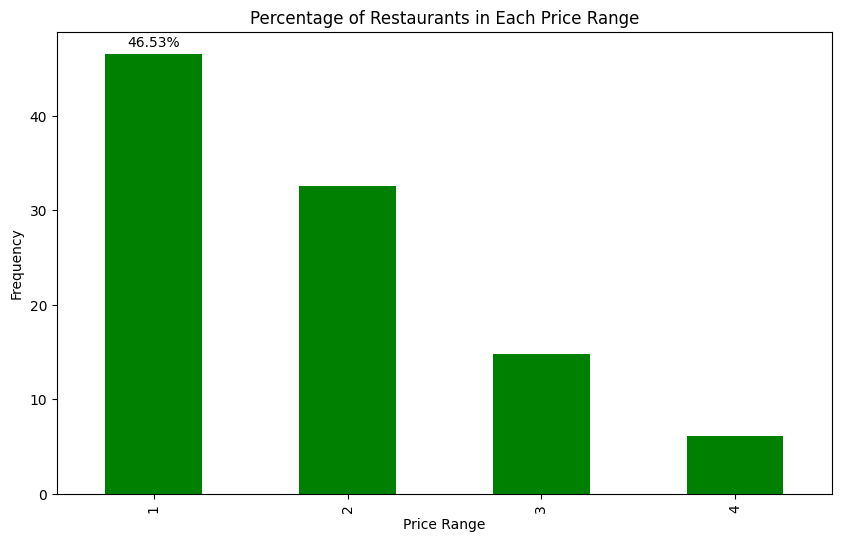

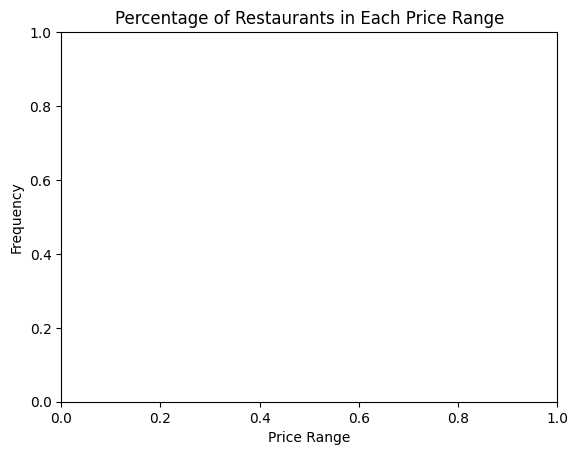

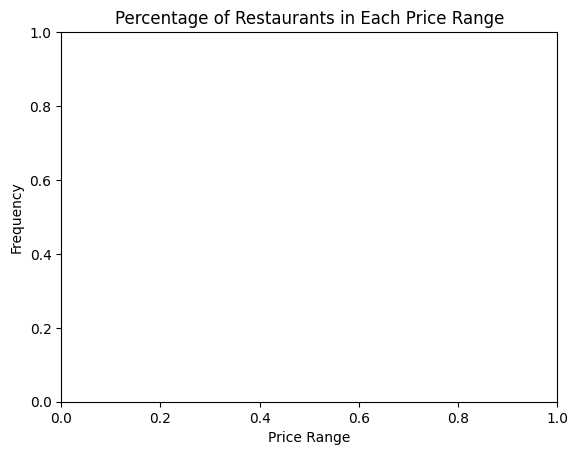

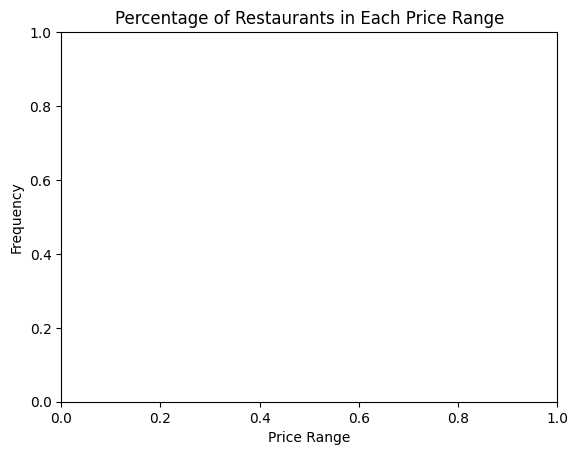

In [ ]:

fig,ax=plt.subplots(figsize=(10,6))
percentage_per_price_range.plot(kind='bar',ax=ax,color='green')
for bar in ax.containers[0]:
  height=bar.get_height()
  ax.annotate(f'{height:.2f}%',xy=(bar.get_x()+bar.get_width()/2,height),xytext=(0,3),textcoords='offset points',ha='center',va='bottom')
  plt.title('Percentage of Restaurants in Each Price Range')
  plt.xlabel('Price Range')
  plt.ylabel('Frequency')
  plt.show()

# **TASK 4**

# **Task: Online Delivery**

# Dateremine the percentage of restaurents that offer online delivery

In [ ]:
total_online_delivery_restaurents=len(df[df['Has Online delivery']=='Yes'])
total_restaurents=len(df)
percentage_online_delivery=(total_online_delivery_restaurents/total_restaurents)*100
print("the percentage of restaurents that offer online delivery is",percentage_online_delivery)

the percentage of restaurents that offer online delivery is 25.662234321013504


# The average rating of restaurants with and without online delivery

In [ ]:

#Average rating restaurants with online delivary:
restaurants_with_online_delivary=df[df['Has Online delivery']=='Yes']
average_rating_with_online_delivary=restaurants_with_online_delivary['Aggregate rating'].mean()
print('average rating of restaurants with online delivary is:',(average_rating_with_online_delivary))


average rating of restaurants with online delivary is: 3.2488372093023257


In [ ]:
#Average rating restaurants without onloine delivary:
restaurants_without_online_delivary=df[df['Has Online delivery']=='No']
average_rating_without_online_delivary=restaurants_without_online_delivary['Aggregate rating'].mean()
print('average_rating_without_online_delivary:',round(average_rating_without_online_delivary,2))

average_rating_without_online_delivary: 2.47
